In [5]:
! pip install numpy matplotlib scipy

# Bessel–Gauss beam radial profile

This notebook reproduces the normalized radial line profile shown in Fig. 3 of Rao (2024), using the $z=0$ form of the Bessel–Gauss intensity:

$$
I_\ell^{BG}(r, z=0) = J_\ell^2(k_r r)\exp\left(-\frac{2r^2}{w_0^2}\right).
$$

For Fig. 3, use:

- order $\ell=0$
- $k_r = 1.0307\times 10^3\ \mathrm{cm^{-1}}$
- radial coordinate $r$ in cm
- Gaussian beam waist $w_0$ in μm, converted to cm

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
from mpl_toolkits.axes_grid1.inset_locator import inset_axes


In [17]:
# Parameters from the paper's Fig. 3
ell = 0
k_r_cm = 1.0307e3  # radial propagation vector, cm^-1

# The plotted radial range in the paper is 0 to 0.03 cm
r_cm = np.linspace(0, 0.03, 2000)

# Gaussian beam waists in micrometers
w0_um_values = [1000, 500, 250, 100, 50, 30, 10]

def um_to_cm(w_um):
    """Convert micrometers to centimeters."""
    return w_um * 1e-4

def bessel_gauss_intensity_z0(r_cm, w0_um, ell=0, k_r_cm=1.0307e3):
    """
    Bessel-Gauss intensity at z = 0:
        I(r) = |J_ell(k_r r)|^2 * exp(-2 r^2 / w0^2)

    r_cm: radial coordinate in cm
    w0_um: Gaussian waist in micrometers
    ell: Bessel order
    k_r_cm: radial propagation vector in cm^-1
    """
    w0_cm = um_to_cm(w0_um)
    return jv(ell, k_r_cm * r_cm)**2 * np.exp(-2 * r_cm**2 / w0_cm**2)

profiles = {
    w0_um: bessel_gauss_intensity_z0(r_cm, w0_um, ell=ell, k_r_cm=k_r_cm)
    for w0_um in w0_um_values
}


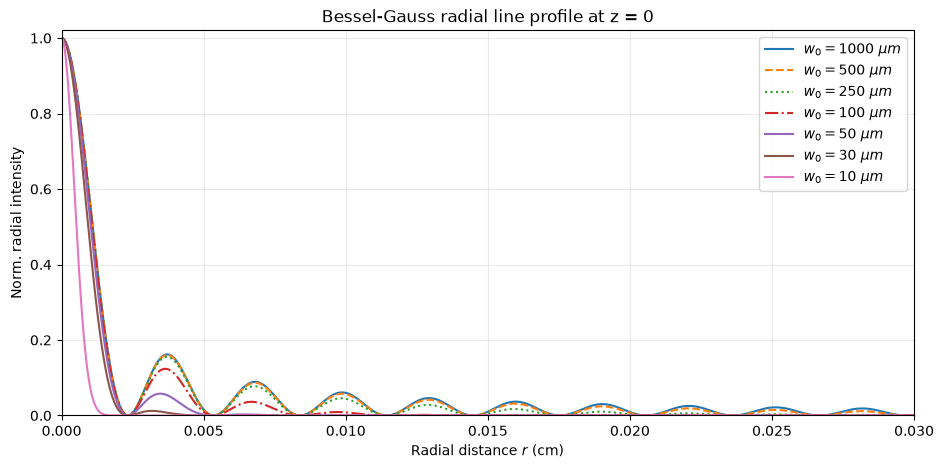

In [18]:
fig, ax = plt.subplots(figsize=(11, 5))

line_styles = {
    1000: "-",
    500: "--",
    250: ":",
    100: "-.",
    50: "-",
    30: "-",
    10: "-",
}

for w0_um in w0_um_values:
    I = profiles[w0_um]
    # Max is 1 at r=0 for ell=0, but normalize explicitly anyway.
    I_norm = I / I.max()
    ax.plot(
        r_cm,
        I_norm,
        linestyle=line_styles[w0_um],
        label=rf"$w_0={w0_um}\ \mu m$",
    )

ax.set_xlim(0, 0.03)
ax.set_ylim(0, 1.02)
ax.set_xlabel(r"Radial distance $r$ (cm)")
ax.set_ylabel("Norm. radial intensity")
ax.set_title("Bessel-Gauss radial line profile at z = 0")
ax.grid(alpha=0.25)
ax.legend(loc="upper right", frameon=True)

plt.show()


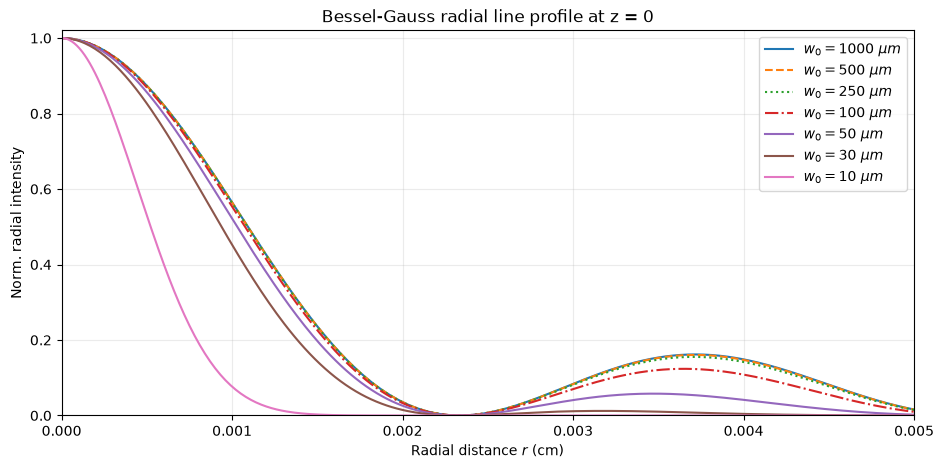

In [37]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
from mpl_toolkits.axes_grid1.inset_locator import inset_axes, mark_inset

# Parameters from the paper's Fig. 3
ell = 0
k_r_cm = 1.0307e3  # radial propagation vector, cm^-1

# The plotted radial range in the paper is 0 to 0.03 cm
r_cm = np.linspace(0, 0.03, 2000)

# Gaussian beam waists in micrometers
w0_um_values = [1000, 500, 250, 100, 50, 30, 10]

def um_to_cm(w_um):
    return w_um * 1e-4

def bessel_gauss_intensity_z0(r_cm, w0_um, ell=0, k_r_cm=1.0307e3):
    w0_cm = um_to_cm(w0_um)
    return jv(ell, k_r_cm * r_cm)**2 * np.exp(-2 * r_cm**2 / w0_cm**2)

profiles = {
    w0_um: bessel_gauss_intensity_z0(r_cm, w0_um, ell=ell, k_r_cm=k_r_cm)
    for w0_um in w0_um_values
}

fig, ax = plt.subplots(figsize=(11, 5))

line_styles = {
    1000: "-",
    500: "--",
    250: ":",
    100: "-.",
    50: "-",
    30: "-",
    10: "-",
}

for w0_um in w0_um_values:
    I = profiles[w0_um]
    I_norm = I / I.max()
    ax.plot(
        r_cm,
        I_norm,
        linestyle=line_styles[w0_um],
        label=rf"$w_0={w0_um}\ \mu m$",
    )

ax.set_xlim(0, 0.005)
ax.set_ylim(0, 1.02)
ax.set_xlabel(r"Radial distance $r$ (cm)")
ax.set_ylabel("Norm. radial intensity")
ax.set_title("Bessel-Gauss radial line profile at z = 0")
ax.grid(alpha=0.25)
ax.legend(loc="upper right", frameon=True)

plt.show()

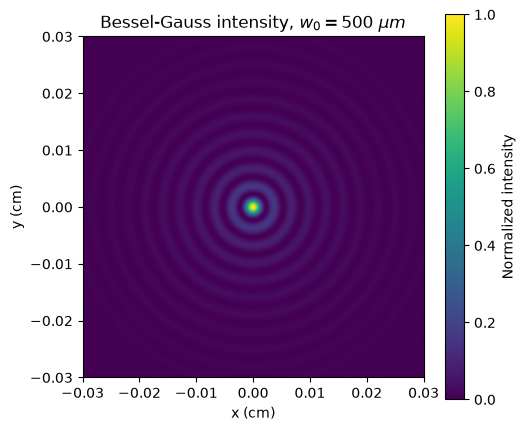

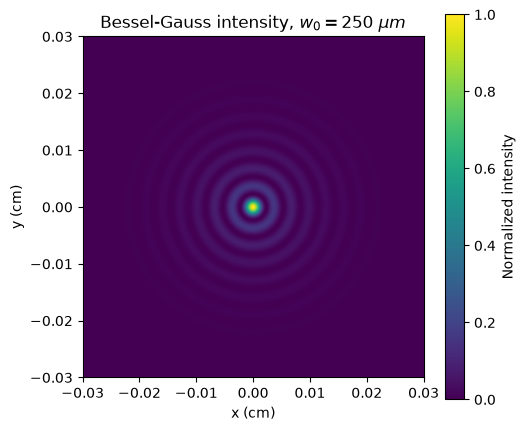

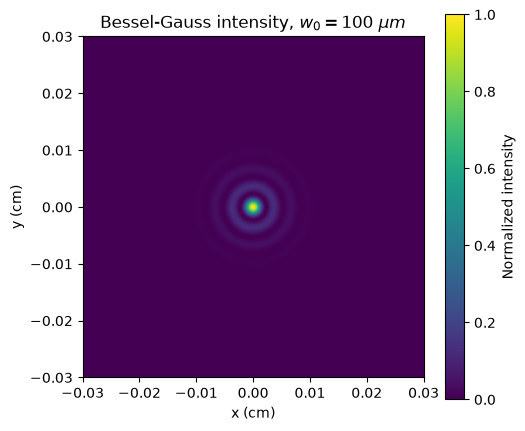

In [19]:
# Optional: make the 2D transverse cross-section images for selected waists.
# These are analogous to the three inset images in the paper.

selected_w0_um = [500, 250, 100]
extent_cm = 0.03
n = 600

x_cm = np.linspace(-extent_cm, extent_cm, n)
y_cm = np.linspace(-extent_cm, extent_cm, n)
X_cm, Y_cm = np.meshgrid(x_cm, y_cm)
R_cm = np.sqrt(X_cm**2 + Y_cm**2)

for w0_um in selected_w0_um:
    I2 = bessel_gauss_intensity_z0(R_cm, w0_um, ell=ell, k_r_cm=k_r_cm)
    I2_norm = I2 / I2.max()

    fig, ax = plt.subplots(figsize=(5.5, 5))
    im = ax.imshow(
        I2_norm,
        extent=[-extent_cm, extent_cm, -extent_cm, extent_cm],
        origin="lower",
        cmap="viridis",
        vmin=0,
        vmax=1,
    )
    ax.set_aspect("equal")
    ax.set_xlabel("x (cm)")
    ax.set_ylabel("y (cm)")
    ax.set_title(rf"Bessel-Gauss intensity, $w_0={w0_um}\ \mu m$")
    fig.colorbar(im, ax=ax, label="Normalized intensity")
    plt.show()


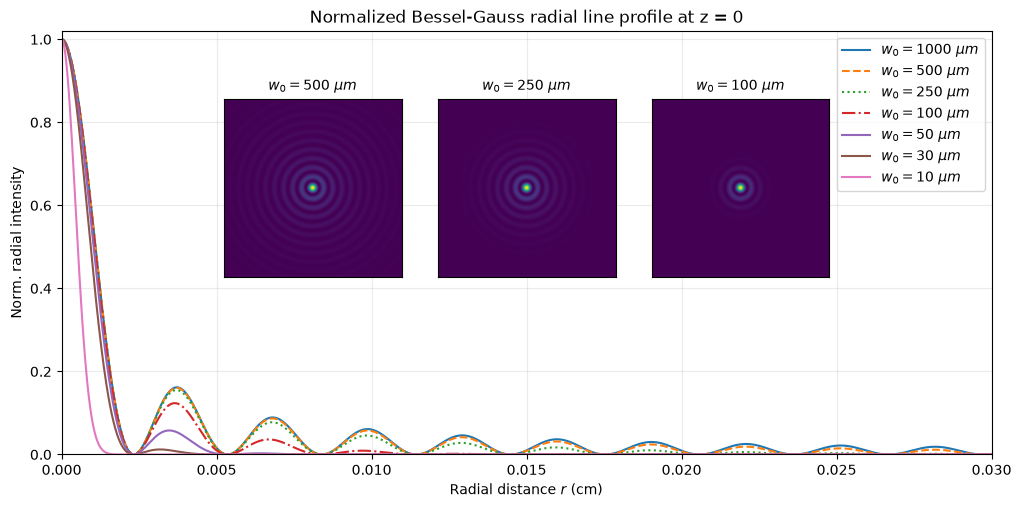

In [ ]:
# Optional: one figure with the radial line profile and three inset cross-sections.

fig, ax = plt.subplots(figsize=(12, 5.5))

for w0_um in w0_um_values:
    I = profiles[w0_um]
    ax.plot(
        r_cm,
        I / I.max(),
        linestyle=line_styles[w0_um],
        label=rf"$w_0={w0_um}\ \mu m$",
    )

ax.set_xlim(0, 0.03)
ax.set_ylim(0, 1.02)
ax.set_xlabel(r"Radial distance $r$ (cm)")
ax.set_ylabel("Norm. radial intensity")
ax.set_title("Bessel-Gauss radial line profile at z = 0, normalized")
ax.grid(alpha=0.25)
ax.legend(loc="upper right", frameon=True)

# Inset positions: [x0, y0, width, height] in axes coordinates
positions = [
    [0.16, 0.42, 0.22, 0.42],
    [0.39, 0.42, 0.22, 0.42],
    [0.62, 0.42, 0.22, 0.42],
]

for pos, w0_um in zip(positions, [500, 250, 100]):
    axins = ax.inset_axes(pos)
    I2 = bessel_gauss_intensity_z0(R_cm, w0_um, ell=ell, k_r_cm=k_r_cm)
    I2_norm = I2 / I2.max()
    axins.imshow(
        I2_norm,
        extent=[-extent_cm, extent_cm, -extent_cm, extent_cm],
        origin="lower",
        cmap="viridis",
        vmin=0,
        vmax=1,
    )
    axins.set_xticks([])
    axins.set_yticks([])
    axins.set_title(rf"$w_0={w0_um}\ \mu m$", fontsize=10)

plt.show()


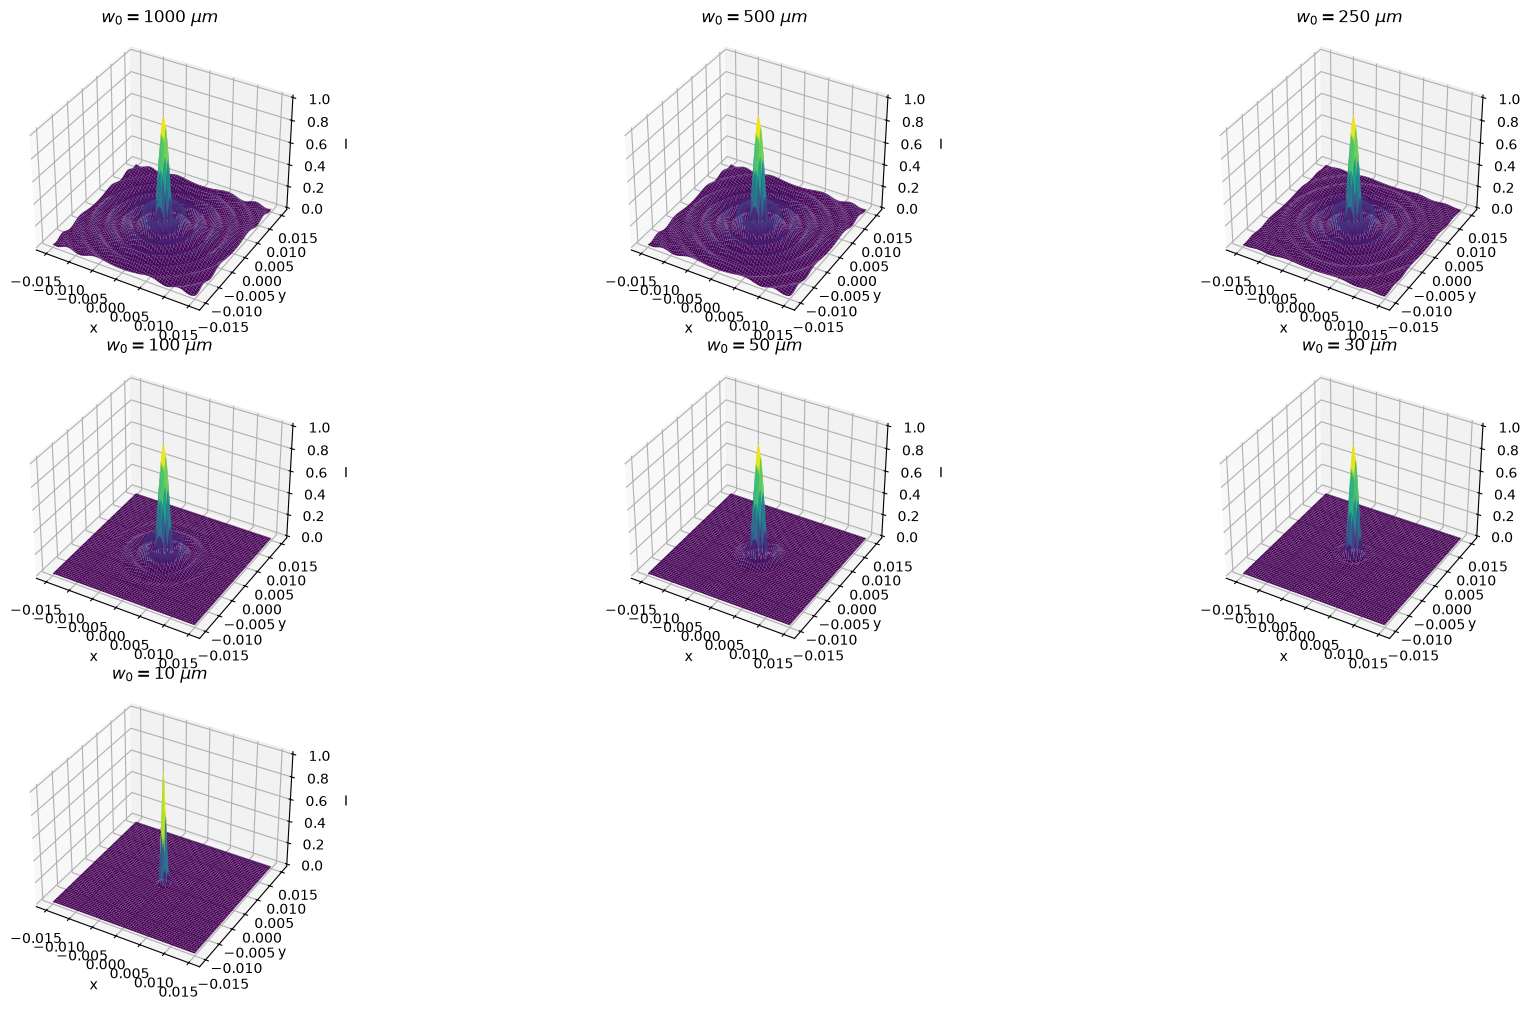

In [22]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.special import jv
from mpl_toolkits.mplot3d import Axes3D  # activates 3D plotting

# Parameters
ell = 0
k_r_cm = 1.0307e3  # cm^-1

def um_to_cm(w_um):
    return w_um * 1e-4

def bessel_gauss_intensity_z0(r_cm, w0_um, ell=0, k_r_cm=1.0307e3):
    w0_cm = um_to_cm(w0_um)
    return jv(ell, k_r_cm * r_cm)**2 * np.exp(-2 * r_cm**2 / w0_cm**2)

# 2D grid in x,y
extent_cm = 0.015   # smaller extent helps the 3D structure stand out
n = 250

x_cm = np.linspace(-extent_cm, extent_cm, n)
y_cm = np.linspace(-extent_cm, extent_cm, n)
X_cm, Y_cm = np.meshgrid(x_cm, y_cm)
R_cm = np.sqrt(X_cm**2 + Y_cm**2)

selected_w0_um = [1000, 500, 250, 100, 50, 30, 10]

fig = plt.figure(figsize=(18, 10))

for i, w0_um in enumerate(selected_w0_um, start=1):
    Z = bessel_gauss_intensity_z0(R_cm, w0_um, ell=ell, k_r_cm=k_r_cm)
    Z = Z / Z.max()

    ax = fig.add_subplot(3, 3, i, projection='3d')
    ax.plot_surface(X_cm, Y_cm, Z, rstride=4, cstride=4, cmap='viridis', linewidth=0)

    ax.set_title(rf"$w_0 = {w0_um}\ \mu m$")
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("I")
    ax.view_init(elev=35, azim=-60)

plt.tight_layout()
plt.show()

## What to look for

As $w_0$ increases, the Gaussian envelope becomes wider, so more Bessel rings survive. In the limit of very large $w_0$, the expression approaches the ideal Bessel profile:

$$
I_\ell(r) = J_\ell^2(k_r r).
$$

As $w_0$ decreases, the Gaussian envelope suppresses the rings, and the profile becomes more Gaussian-like.